In [3]:
# 📌 1. Import thư viện cần thiết
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt hiển thị đồ họa đẹp hơn
sns.set(style="whitegrid")

# 📌 2. Đọc dữ liệu từ file CSV (chỉnh đúng đường dẫn file của bạn)
df = pd.read_csv("../data/lazada_all_reviews2.csv")


# 📌 3. Khám phá nhanh dữ liệu
print("Các cột trong dữ liệu:", df.columns)
print("Giá trị duy nhất trong cột Rating:", df['Số sao'].unique())
print(df['Số sao'].describe())   


Các cột trong dữ liệu: Index(['STT', 'Trang', 'Thời gian đánh giá', 'Tên', 'Chứng nhận', 'Nội dung',
       'Phân loại', 'Lượt thích', 'Số sao', 'URL'],
      dtype='object')
Giá trị duy nhất trong cột Rating: [5 4 3 1 2]
count    11041.000000
mean         4.904175
std          0.502585
min          1.000000
25%          5.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: Số sao, dtype: float64


In [ ]:
import pandas as pd

df = pd.read_csv('../lazada_all_reviews.csv')  # hoặc điều chỉnh path cho phù hợp


FileNotFoundError: [Errno 2] No such file or directory: 'ten_file.csv'

In [2]:
# 📌 4. Tiền xử lý dữ liệu
# Loại bỏ các dòng không có đánh giá hoặc giá trị không hợp lệ
df = df.dropna(subset=['Số sao'])
df = df[df['Số sao'].between(1, 5)]  # Chỉ giữ từ 1 đến 5 sao
df['Số sao'] = df['Số sao'].astype(int)


NameError: name 'df' is not defined

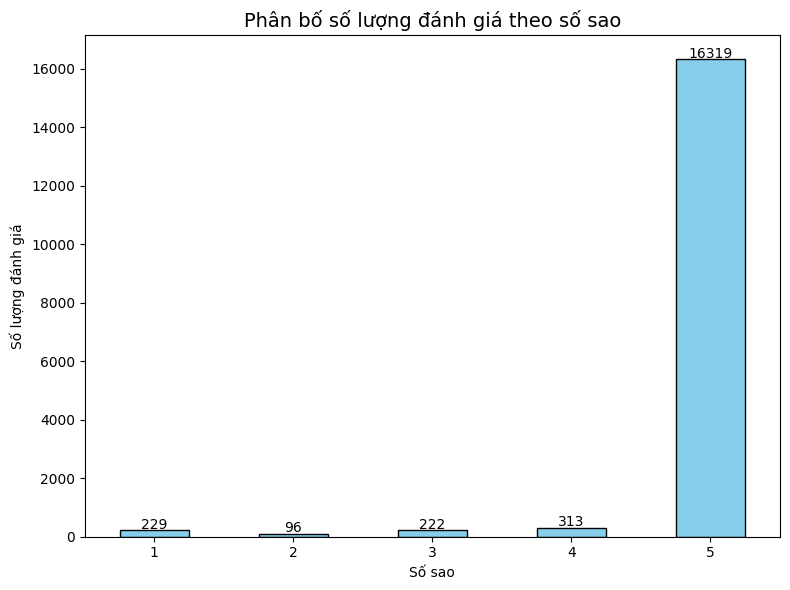

In [39]:
import matplotlib.pyplot as plt

rating_counts = df_merged['Số sao'].value_counts().sort_index()

plt.figure(figsize=(8, 6))
ax = rating_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Phân bố số lượng đánh giá theo số sao", fontsize=14)
plt.xlabel("Số sao")
plt.ylabel("Số lượng đánh giá")
plt.xticks(rotation=0)

for i, v in enumerate(rating_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()


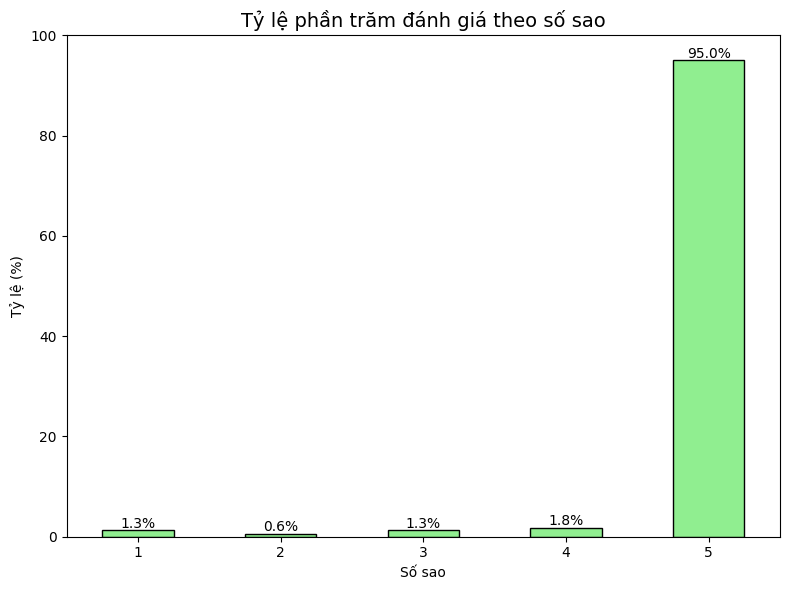

In [42]:
import matplotlib.pyplot as plt

# Tính phần trăm
rating_counts = df_merged['Số sao'].value_counts().sort_index()
rating_percent = (rating_counts / rating_counts.sum()) * 100

# Vẽ biểu đồ cột thể hiện phần trăm
plt.figure(figsize=(8, 6))
ax = rating_percent.plot(kind='bar', color='lightgreen', edgecolor='black')

plt.title("Tỷ lệ phần trăm đánh giá theo số sao", fontsize=14)
plt.xlabel("Số sao")
plt.ylabel("Tỷ lệ (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)

# Ghi phần trăm lên đầu cột
for i, v in enumerate(rating_percent.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()


C:\Users\QUANG TRUNG\AppData\Local\Temp\ipykernel_15372\1251125077.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_avg, y="Tên rút gọn", x="mean", palette="magma")
C:\Users\QUANG TRUNG\AppData\Local\Temp\ipykernel_15372\1251125077.py:29: UserWarning: Glyph 20008 (\N{CJK UNIFIED IDEOGRAPH-4E28}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\QUANG TRUNG\AppData\Local\Temp\ipykernel_15372\1251125077.py:29: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\QUANG TRUNG\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20008 (\N{CJK UNIFIED IDEOGRAPH-4E28}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\QUANG TRUNG\AppData\Roaming\Python\Python313\site-pack

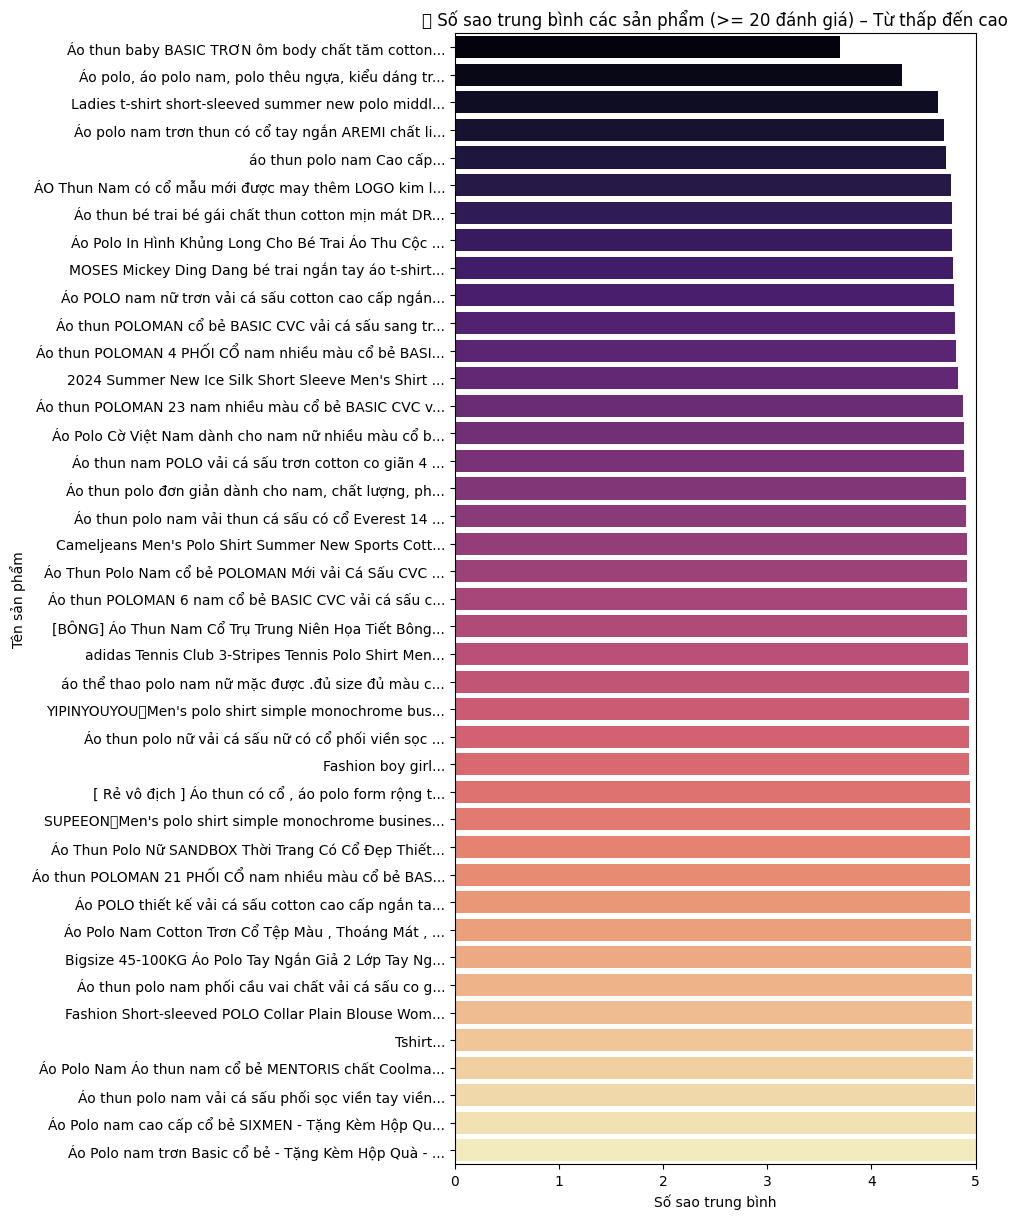

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu
df_reviews = pd.read_csv("../data/lazada_all_reviews2.csv")
df_products = pd.read_csv("../data/lazada_all_products2.csv")

# Tiền xử lý
df_reviews["Số sao"] = pd.to_numeric(df_reviews["Số sao"], errors="coerce")
df = pd.merge(df_reviews, df_products[["URL", "Tên sản phẩm"]], on="URL", how="left")

# Tính trung bình số sao
df_avg = df.groupby("Tên sản phẩm")["Số sao"].agg(["mean", "count"]).reset_index()
df_avg = df_avg[df_avg["count"] >= 20]
df_avg = df_avg.sort_values("mean", ascending=True)

# Tạo cột rút gọn tên sản phẩm
df_avg["Tên rút gọn"] = df_avg["Tên sản phẩm"].str.slice(0, 50) + "..."

# Vẽ biểu đồ
plt.figure(figsize=(10, len(df_avg) * 0.3))
sns.barplot(data=df_avg, y="Tên rút gọn", x="mean", palette="magma")

plt.title("📉 Số sao trung bình các sản phẩm (>= 20 đánh giá) – Từ thấp đến cao")
plt.xlabel("Số sao trung bình")
plt.ylabel("Tên sản phẩm")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()
